# 03 - Augmentation: evidence, policy and preview

Owner: Alejandro (AUG). This notebook decides **what to augment and why**, using measurements on the data the
team trains on (`data/processed/`), and turns the decisions into a versioned policy that everybody shares.

| Output                                                | Where                                                       | Used for                                                                                                                                                                                                     |
| ----------------------------------------------------- | ----------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Augmentation policy (one arm per ablation experiment) | [`configs/augmentation.yaml`](../configs/augmentation.yaml) | **Training.** Julia loads it with `load_policy(...)`. It is applied _online_ (inside the training loop), so every teammate trains with identical settings and there are no augmented copies to keep in sync. |
| Preview sample                                        | `data/augmented/`                                           | **Looking only.** A small stratified sample of train images with the policy applied, plus contact sheets. Never a training set.                                                                              |

`data/raw/` and `data/processed/` are only read. Val and test images are never augmented: the export reads
`images/train` and nothing else.

Prerequisite: run the data pipeline first (`uv run python scripts/process_data.py`). `data/raw/` is optional;
without it, section 1 is skipped. Sections 1-7 are measurements, 8 is the policy, 9 is the preview and export,
10 is the hand-off.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import re
import time
import zlib
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap, hsv_to_rgb
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

from vpc2.data import io
from vpc2.data.augmentation import (
    CLASS_COLORS_RGB,
    augment_sample,
    export_preview,
    list_arms,
    load_policy,
    simple_mosaic,
)
from vpc2.data.processing import parse_yolo_label

cv2.setNumThreads(1)  # the thread pool below already uses every core

ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
AUGMENTED_DIR = ROOT / "data" / "augmented"

ARM = "proposed"  # arm of configs/augmentation.yaml previewed in sections 8-9
EXPORT_TO_DISK = True  # write the preview sample to data/augmented/ (train images only)
PER_CLASS = (
    8  # train images per class in the preview; None = every train image (~150 MB per variant)
)
N_VARIANTS = 3  # augmented copies per sampled image
SEED = 42
IMG = 416  # every image in the dataset is 416x416
PHOTO_DPI = 85  # figures made of photos: a lower resolution keeps the notebook small

In [2]:
# Chart tokens: team palette on a light surface. The class palette passed the validator (worst adjacent
# colour-blind separation dE 9.1); aqua, yellow and magenta sit below 3:1 contrast, so class charts carry
# direct labels or a table twin. Magnitude comparisons use one accent against grey instead of six hues.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb",
    "#0b0b0b",
    "#52514e",
    "#898781",
    "#e1e0d9",
    "#c3c2b7",
)
ACCENT, CONTEXT = "#2a78d6", "#c3c2b7"
SPLIT_COLORS = {"train": "#2a78d6", "valid": "#eb6834", "val": "#eb6834", "test": "#1baf7a"}
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK_2,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": INK,
        "axes.titlecolor": INK,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlelocation": "left",
        "axes.titlesize": 10.5,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "font.family": "sans-serif",
        "figure.dpi": 110,
        "savefig.dpi": 110,
    }
)


def md_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    lines += ["| " + " | ".join(str(cell) for cell in row) + " |" for row in rows]
    return Markdown("\n".join(lines))


def hbar(
    ax, labels, values, *, highlight=None, fmt="{:,.0f}", xlim=None, percent=False, show_labels=True
):
    # one accent for the bar the story is about, grey for the rest, value at the tip
    colors = [ACCENT if i == highlight else CONTEXT for i in range(len(values))]
    ax.barh(range(len(values)), values, color=colors, height=0.55)
    ax.set_yticks(range(len(values)), labels)
    ax.tick_params(axis="y", length=0, labelleft=show_labels)
    ax.set_ylim(len(values) - 0.5, -0.5)  # first row on top
    ax.grid(axis="y", visible=False)
    span = 100 if percent else (xlim if xlim is not None else max(values))
    for i, value in enumerate(values):
        ax.text(value + span * 0.015, i, fmt.format(value), va="center", fontsize=8.5, color=INK_2)
    ax.set_xlim(0, span * 1.2)
    if percent:
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.spines["bottom"].set_bounds(0, 100)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))


def heat(ax, matrix, xlabels, ylabels, fmt="{:,.0f}"):
    ax.imshow(matrix, cmap=BLUE_RAMP, aspect="auto", vmin=0)
    ax.set_xticks(range(len(xlabels)), xlabels, rotation=30, ha="right")
    ax.set_yticks(range(len(ylabels)), ylabels)
    ax.set_xticks(np.arange(matrix.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(matrix.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="both", visible=False)
    ax.grid(which="minor", visible=True, color=SURFACE, linewidth=2)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    vmax = matrix.max() if matrix.max() > 0 else 1
    for (row, col), value in np.ndenumerate(matrix):
        ax.text(
            col,
            row,
            fmt.format(value),
            ha="center",
            va="center",
            fontsize=8.5,
            color="white" if value / vmax > 0.5 else INK,
        )


def draw_boxes(ax, image, boxes, linewidth=1.2):
    ax.imshow(image)
    ax.axis("off")
    height, width = image.shape[:2]
    for class_id, xc, yc, w, h in boxes:
        color = np.array(CLASS_COLORS_RGB[int(class_id)]) / 255
        ax.add_patch(
            plt.Rectangle(
                ((xc - w / 2) * width, (yc - h / 2) * height),
                w * width,
                h * height,
                fill=False,
                edgecolor=color,
                linewidth=linewidth,
            )
        )


def class_legend(fig, y=0.0):
    handles = [
        Patch(facecolor=np.array(c) / 255, label=n) for c, n in zip(CLASS_COLORS_RGB, CLASS_NAMES)
    ]
    fig.legend(handles=handles, loc="lower center", ncol=NC, bbox_to_anchor=(0.5, y))

In [3]:
if not (PROCESSED_DIR / "data.yaml").is_file():
    raise FileNotFoundError(
        "data/processed/ is missing. Run first: uv run python scripts/process_data.py"
    )

CLASS_NAMES = io.class_names_from_yaml(io.load_yolo_yaml(PROCESSED_DIR / "data.yaml"))
NC = len(CLASS_NAMES)
SPLITS = ("train", "val", "test")

paths, split_of, boxes_of = [], [], []
for split in SPLITS:
    for image_path in io.list_images(PROCESSED_DIR / "images" / split):
        label_path = io.matching_label_path(image_path, PROCESSED_DIR / "labels" / split)
        parsed, _, _ = parse_yolo_label(label_path, num_classes=NC)
        paths.append(image_path)
        split_of.append(split)
        rows = [[b.class_id, b.x_center, b.y_center, b.width, b.height] for b in parsed]
        boxes_of.append(np.array(rows, dtype=float).reshape(-1, 5))

N = len(paths)
stems = np.array([p.stem for p in paths])
split_of = np.array(split_of)
n_boxes = np.array([len(b) for b in boxes_of])
majority = np.array([np.bincount(b[:, 0].astype(int), minlength=NC).argmax() for b in boxes_of])
BOX = np.vstack(boxes_of)  # every box: class, xc, yc, w, h (normalised)
BOX_IMG = np.repeat(np.arange(N), n_boxes)  # image index of each box
# the source class is encoded in the file name (biodegradable1001_jpg.rf...)
prefix = np.array([(m.group(0) if (m := re.match(r"[a-z]+", s.lower())) else "?") for s in stems])

# Roboflow's own split of each image, from directory listings only (data/raw is optional)
origin, raw_root = None, None
try:
    raw_root = io.discover_raw_dataset(RAW_DIR)
    listing = {
        p.stem: name
        for name in ("train", "valid", "test")
        for p in io.list_images(raw_root / name / "images")
    }
    origin = np.array([listing.get(s, "?") for s in stems])
except FileNotFoundError:
    print("data/raw/ not found: section 1 is skipped (it needs Roboflow's original split).")
RAW_OK = origin is not None

print(f"{N:,} images, {len(BOX):,} boxes, classes: {CLASS_NAMES}")
print("our splits:", {s: int((split_of == s).sum()) for s in SPLITS})

10,464 images, 74,073 boxes, classes: ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']
our splits: {'train': 7326, 'val': 2093, 'test': 1045}


In [4]:
# One pass over every image (threads: OpenCV releases the GIL). Global colour/brightness/sharpness numbers,
# a 32x32 thumbnail (for the duplicate check) and the colour of up to 3 random boxes per image.
STAT_COLUMNS = ["luma_mean", "luma_std", "p1", "p99", "sat_mean", "val_mean", "lap_var", "r", "g", "b",
                "clip_hi", "clip_lo", "top", "bottom", "left", "right", "ring_mean", "ring_std"]  # fmt: skip
N_GLOBAL = 12  # the first 12 carry no layout information (used in section 6)
THUMB = 32


def analyze_image(item):
    path, boxes = item
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    height, width = gray.shape
    ring = np.ones(gray.shape, dtype=bool)
    ring[10:-10, 10:-10] = False
    p1, p99 = np.percentile(gray, [1, 99])
    blue, green, red = bgr.reshape(-1, 3).mean(axis=0)
    stats = [gray.mean(), gray.std(), p1, p99, hsv[..., 1].mean(), hsv[..., 2].mean(),
             cv2.Laplacian(gray, cv2.CV_64F).var(), red, green, blue,
             (gray >= 250).mean(), (gray <= 5).mean(),
             gray[: height // 2].mean(), gray[height // 2 :].mean(),
             gray[:, : width // 2].mean(), gray[:, width // 2 :].mean(),
             gray[ring].mean(), gray[ring].std()]  # fmt: skip
    thumb = cv2.resize(gray, (THUMB, THUMB), interpolation=cv2.INTER_AREA).astype(np.float32)

    rng = np.random.default_rng(zlib.crc32(path.name.encode()))
    box_colors = []
    for class_id, xc, yc, w, h in boxes[rng.permutation(len(boxes))]:
        x1, x2 = int(max(0, (xc - w / 2) * width)), int(min(width, (xc + w / 2) * width))
        y1, y2 = int(max(0, (yc - h / 2) * height)), int(min(height, (yc + h / 2) * height))
        if min(x2 - x1, y2 - y1) < 12:
            continue
        crop = hsv[y1:y2, x1:x2].reshape(-1, 3).astype(np.float32)
        chromatic = (crop[:, 1] >= 40) & (crop[:, 2] >= 40)
        if chromatic.sum() >= 20:
            angle = crop[chromatic, 0] * (2 * np.pi / 180)  # OpenCV hue runs 0-179
            hue = np.degrees(np.arctan2(np.sin(angle).mean(), np.cos(angle).mean())) % 360
        else:
            hue = np.nan
        box_colors.append((int(class_id), crop[:, 1].mean(), chromatic.mean(), hue))
        if len(box_colors) == 3:
            break
    return np.array(stats, dtype=np.float32), thumb, box_colors


start = time.time()
with ThreadPoolExecutor(max_workers=os.cpu_count()) as pool:
    results = list(pool.map(analyze_image, zip(paths, boxes_of)))
STATS = np.stack([r[0] for r in results])
THUMBS = np.stack([r[1] for r in results])
BOX_COLORS = [r[2] for r in results]
S = {name: STATS[:, i] for i, name in enumerate(STAT_COLUMNS)}
print(f"analysed {N:,} images in {time.time() - start:.0f} s")

analysed 10,464 images in 9 s


## 1. What Roboflow already did to this data

The export's README says version 2 was augmented before we downloaded it. It does not say _which split_ got the
augmentation, and that decides which orientation augmentations are still worth adding.

A random flip or 90-degree turn leaves fingerprints. Top-versus-bottom and left-versus-right brightness, and the
width-to-height ratio of boxes, all become symmetric around zero, while natural photos are not (light comes from
above, bottles stand upright). So each Roboflow split can be tested for them.


In [5]:
ORIGINS = ("train", "valid", "test")
if RAW_OK:
    readme = (raw_root / "README.roboflow.txt").read_text(encoding="utf-8")
    print(readme[readme.index("The following pre-processing") :].strip(), end="\n\n")

    rows = []
    for split in SPLITS:
        in_split = split_of == split
        counts = Counter(origin[in_split])
        cells_ = [f"{counts[o]:,} ({100 * counts[o] / in_split.sum():.0f}%)" for o in ORIGINS]
        rows.append([split, f"{in_split.sum():,}", *cells_])
    display(
        Markdown(
            "**Where each of our processed splits came from** (Roboflow's original split of each image)"
        )
    )
    display(
        md_table(
            [
                "our split",
                "images",
                "from Roboflow train",
                "from Roboflow valid",
                "from Roboflow test",
            ],
            rows,
        )
    )

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF-orientation stripping)
* Resize to 416x416 (Stretch)

The following augmentation was applied to create 1 versions of each source image:
* 50% probability of horizontal flip
* 50% probability of vertical flip
* Equal probability of one of the following 90-degree rotations: none, clockwise, counter-clockwise, upside-down



**Where each of our processed splits came from** (Roboflow's original split of each image)

| our split | images | from Roboflow train | from Roboflow valid | from Roboflow test |
|---|---|---|---|---|
| train | 7,326 | 5,107 (70%) | 1,475 (20%) | 744 (10%) |
| val | 2,093 | 1,455 (70%) | 437 (21%) | 201 (10%) |
| test | 1,045 | 762 (73%) | 186 (18%) | 97 (9%) |

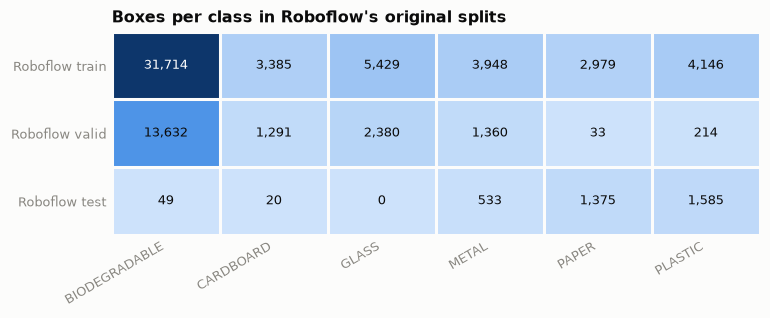

In [6]:
if RAW_OK:
    counts = np.array(
        [
            [int(((origin[BOX_IMG] == o) & (BOX[:, 0] == c)).sum()) for c in range(NC)]
            for o in ORIGINS
        ]
    )
    fig, ax = plt.subplots(figsize=(7.6, 2.4))
    heat(ax, counts, CLASS_NAMES, [f"Roboflow {o}" for o in ORIGINS])
    ax.set_title("Boxes per class in Roboflow's original splits")
    plt.show()

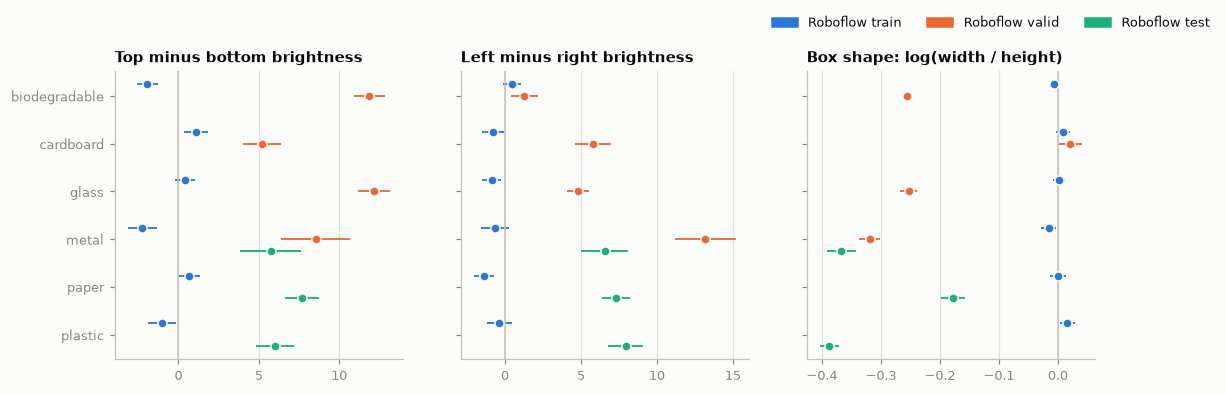

**Table twin, source class `metal`** (the only class present in all three Roboflow splits; mean +- 1 standard error)

| measure | split | n | mean |
|---|---|---|---|
| Top minus bottom brightness | Roboflow train | 874 | -2.236 +- 0.912 |
| Top minus bottom brightness | Roboflow valid | 204 | +8.530 +- 2.145 |
| Top minus bottom brightness | Roboflow test | 170 | +5.731 +- 1.891 |
| Left minus right brightness | Roboflow train | 874 | -0.636 +- 0.913 |
| Left minus right brightness | Roboflow valid | 204 | +13.190 +- 2.014 |
| Left minus right brightness | Roboflow test | 170 | +6.571 +- 1.559 |
| Box shape: log(width / height) | Roboflow train | 3,038 | -0.016 +- 0.013 |
| Box shape: log(width / height) | Roboflow valid | 848 | -0.319 +- 0.018 |
| Box shape: log(width / height) | Roboflow test | 573 | -0.367 +- 0.024 |

In [7]:
if RAW_OK:
    TOP_MINUS_BOTTOM = S["top"] - S["bottom"]
    LEFT_MINUS_RIGHT = S["left"] - S["right"]
    LOG_WH = np.log(BOX[:, 3] / BOX[:, 4])
    box_origin, box_prefix = origin[BOX_IMG], prefix[BOX_IMG]
    groups = sorted(set(prefix))
    measures = [
        ("Top minus bottom brightness", TOP_MINUS_BOTTOM, origin, prefix),
        ("Left minus right brightness", LEFT_MINUS_RIGHT, origin, prefix),
        ("Box shape: log(width / height)", LOG_WH, box_origin, box_prefix),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
    metal_rows = []
    for ax, (title, values, by_origin, by_prefix) in zip(axes, measures):
        for oi, o in enumerate(ORIGINS):
            for gi, g in enumerate(groups):
                v = values[(by_origin == o) & (by_prefix == g)]
                if len(v) < 30:
                    continue
                se = v.std() / np.sqrt(len(v))
                ax.errorbar(
                    v.mean(),
                    gi + (oi - 1) * 0.24,
                    xerr=se,
                    fmt="o",
                    color=SPLIT_COLORS[o],
                    ms=6,
                    elinewidth=1.2,
                    markeredgecolor=SURFACE,
                    markeredgewidth=1,
                )
                if g == "metal":
                    metal_rows.append(
                        [title, f"Roboflow {o}", f"{len(v):,}", f"{v.mean():+.3f} +- {se:.3f}"]
                    )
        ax.axvline(0, color=AXIS, lw=1)
        ax.set_title(title, fontsize=10)
        ax.grid(axis="y", visible=False)
    axes[0].set_yticks(range(len(groups)), groups)
    axes[0].invert_yaxis()
    fig.legend(handles=[Patch(color=SPLIT_COLORS[o], label=f"Roboflow {o}") for o in ORIGINS],
               loc="upper right", ncol=3, bbox_to_anchor=(1.0, 1.06))  # fmt: skip
    plt.show()
    display(
        Markdown(
            "**Table twin, source class `metal`** (the only class present in all three Roboflow splits; mean +- 1 standard error)"
        )
    )
    display(md_table(["measure", "split", "n", "mean"], metal_rows))

**Reading.** Roboflow's train split is symmetric on all three measures, and its valid and test splits are not: they
keep the natural lighting gradient and tall objects. So the flips and 90-degree turns were applied to **train
only**. Gabriela's pooled, stratified re-split then spread those train-origin images over every one of our splits
(first table), so about 70% of each processed split, test included, is already orientation-randomised and the rest
is still in natural orientation. Roboflow's own split was also class-disjoint (heatmap: its test has no GLASS and
almost no BIODEGRADABLE or CARDBOARD), which is why re-splitting was necessary and not just a preference.

**Implication.** Offline flips and turns would repeat what is already baked in. What is left to add is orientation
variety for the images still in natural orientation, and variety per image across epochs. Both are cheap and exact
(section 9), and both belong in training, not on disk.


## 2. Class balance

The plan says augmentation should "offset class imbalance". Before choosing a tool, check what kind of imbalance
this is: **images** per class, **boxes** per class, and how many boxes each image carries.


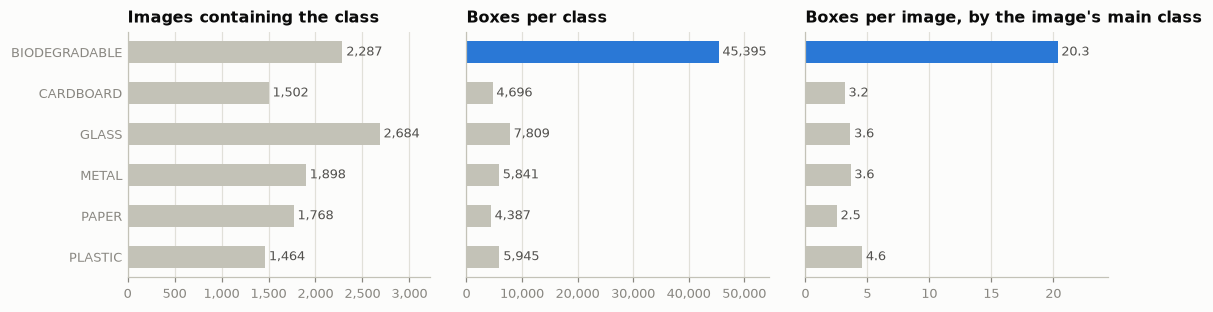

- Images per class span **1,464-2,684** (x1.8); boxes per class span **4,387-45,395** (x10.3).
- BIODEGRADABLE holds **61%** of all boxes with 22% of the images: 20.3 boxes per image against 2.5-4.6 for the other classes (up to 358 in one image).
- **90%** of images contain a single class.

In [8]:
presence = np.array([[(b[:, 0] == c).any() for c in range(NC)] for b in boxes_of])
per_image_counts = np.array([[int((b[:, 0] == c).sum()) for c in range(NC)] for b in boxes_of])
images_with = presence.sum(axis=0)
boxes_per_class = per_image_counts.sum(axis=0)
density = np.array([n_boxes[majority == c].mean() for c in range(NC)])

fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.9), gridspec_kw={"wspace": 0.12})
hbar(axes[0], CLASS_NAMES, images_with)
axes[0].set_title("Images containing the class")
hbar(axes[1], CLASS_NAMES, boxes_per_class, highlight=0, show_labels=False)
axes[1].set_title("Boxes per class")
hbar(axes[2], CLASS_NAMES, density, highlight=0, fmt="{:.1f}", show_labels=False)
axes[2].set_title("Boxes per image, by the image's main class")
plt.show()

others = np.delete(density, 0)
display(
    Markdown(
        f"- Images per class span **{images_with.min():,}-{images_with.max():,}** (x{images_with.max() / images_with.min():.1f}); "
        f"boxes per class span **{boxes_per_class.min():,}-{boxes_per_class.max():,}** (x{boxes_per_class.max() / boxes_per_class.min():.1f}).\n"
        f"- {CLASS_NAMES[0]} holds **{100 * boxes_per_class[0] / boxes_per_class.sum():.0f}%** of all boxes with "
        f"{100 * images_with[0] / N:.0f}% of the images: {density[0]:.1f} boxes per image against {others.min():.1f}-{others.max():.1f} "
        f"for the other classes (up to {n_boxes.max()} in one image).\n"
        f"- **{100 * (presence.sum(axis=1) == 1).mean():.0f}%** of images contain a single class."
    )
)

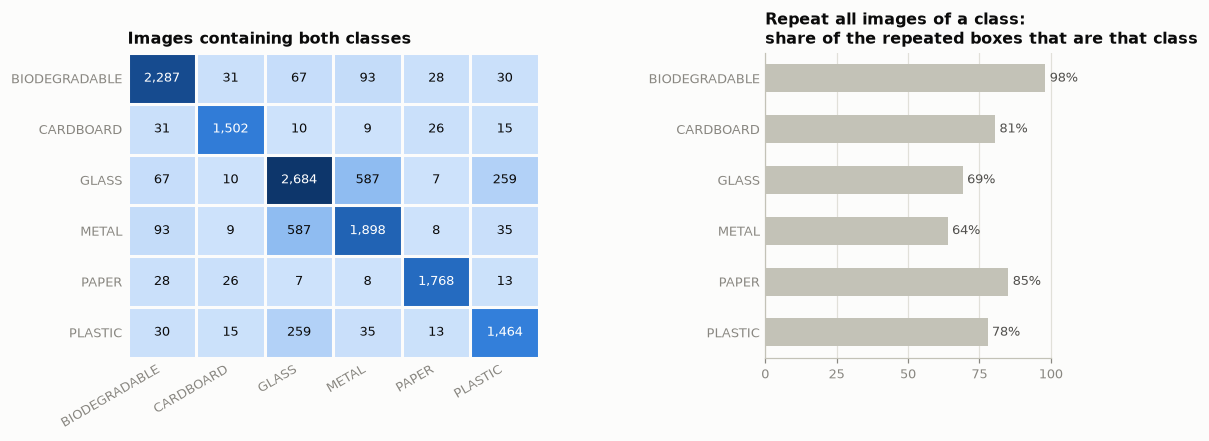

In [9]:
cooc = presence.T.astype(int) @ presence.astype(int)
on_target = np.array(
    [
        100
        * per_image_counts[presence[:, c]].sum(axis=0)[c]
        / per_image_counts[presence[:, c]].sum()
        for c in range(NC)
    ]
)
fig, axes = plt.subplots(
    1, 2, figsize=(11.5, 3.6), gridspec_kw={"width_ratios": [1.2, 1], "wspace": 0.6}
)
heat(axes[0], cooc, CLASS_NAMES, CLASS_NAMES)
axes[0].set_title("Images containing both classes")
hbar(axes[1], CLASS_NAMES, on_target, fmt="{:.0f}%", percent=True)
axes[1].set_title("Repeat all images of a class:\nshare of the repeated boxes that are that class")
plt.show()

**Reading.** Images per class are fairly balanced; boxes are not. The gap comes from how densely each class was
annotated (piles of produce carry dozens of boxes per image), not from how many pictures each class has. So
image-level oversampling is the wrong first tool: repeating an image repeats whatever else is in it (right panel:
the lower the bar, the more unrelated boxes come along, and GLASS and METAL images share many objects).

**Implication.** No sampling change in the first policy. Train a baseline, read per-class AP, and only then decide
whether a class needs class-aware sampling. PAPER and CARDBOARD are the safe candidates: their images are the
purest.


## 3. Objects: size, count, position

Augmentation that moves or rescales the image (translate, scale, mosaic) interacts with how big the objects are
and how close to the border they sit.


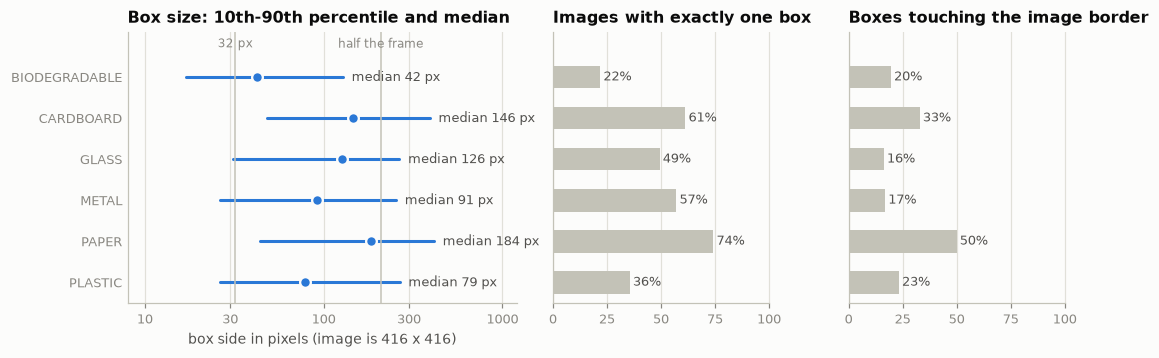

- Boxes under 32 px: BIODEGRADABLE 36%, CARDBOARD 4%, GLASS 11%, METAL 14%, PAPER 5%, PLASTIC 16%.
- Boxes overlapping another box (IoU > 0.3): BIODEGRADABLE 9%, CARDBOARD 22%, GLASS 9%, METAL 6%, PAPER 21%, PLASTIC 15%.
- **49%** of all images hold one object; **22%** of boxes touch a border.

In [10]:
SIDE = np.sqrt(BOX[:, 3] * BOX[:, 4]) * IMG  # geometric-mean side of each box, in pixels at 416
touch = (
    (BOX[:, 1] - BOX[:, 3] / 2 <= 0.005) | (BOX[:, 2] - BOX[:, 4] / 2 <= 0.005)
    | (BOX[:, 1] + BOX[:, 3] / 2 >= 0.995) | (BOX[:, 2] + BOX[:, 4] / 2 >= 0.995)
)  # fmt: skip
single = np.array([100 * (n_boxes[majority == c] == 1).mean() for c in range(NC)])
border = np.array([100 * touch[BOX[:, 0] == c].mean() for c in range(NC)])
small = np.array([100 * (SIDE[BOX[:, 0] == c] < 32).mean() for c in range(NC)])

max_iou = np.zeros(len(BOX))  # overlap with the closest other box of the same image
offset = 0
for boxes in boxes_of:
    n = len(boxes)
    if n > 1:
        x1, y1 = boxes[:, 1] - boxes[:, 3] / 2, boxes[:, 2] - boxes[:, 4] / 2
        x2, y2 = boxes[:, 1] + boxes[:, 3] / 2, boxes[:, 2] + boxes[:, 4] / 2
        iw = np.clip(np.minimum(x2[:, None], x2[None]) - np.maximum(x1[:, None], x1[None]), 0, None)
        ih = np.clip(np.minimum(y2[:, None], y2[None]) - np.maximum(y1[:, None], y1[None]), 0, None)
        inter = iw * ih
        area = boxes[:, 3] * boxes[:, 4]
        iou = inter / (area[:, None] + area[None] - inter)
        np.fill_diagonal(iou, 0)
        max_iou[offset : offset + n] = iou.max(axis=1)
    offset += n
overlap = np.array([100 * (max_iou[BOX[:, 0] == c] > 0.3).mean() for c in range(NC)])

fig, axes = plt.subplots(
    1, 3, figsize=(11.5, 3.2), gridspec_kw={"width_ratios": [1.5, 1, 1], "wspace": 0.12}
)
ax = axes[0]
for i in range(NC):
    p10, p50, p90 = np.percentile(SIDE[BOX[:, 0] == i], [10, 50, 90])
    ax.plot([p10, p90], [i, i], color=ACCENT, lw=2, solid_capstyle="round")
    ax.plot(p50, i, "o", color=ACCENT, ms=7, markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.text(p90 * 1.12, i, f"median {p50:.0f} px", va="center", fontsize=8.5, color=INK_2)
ax.set_xscale("log")
ax.set_xlim(8, 1200)
ax.set_xticks([10, 30, 100, 300, 1000], ["10", "30", "100", "300", "1000"])
ax.minorticks_off()
ax.set_xlabel("box side in pixels (image is 416 x 416)")
for x, label in ((32, "32 px"), (208, "half the frame")):
    ax.axvline(x, color=AXIS, lw=1)
    ax.text(x, -0.8, label, ha="center", va="center", fontsize=8, color=MUTED)
ax.set_yticks(range(NC), CLASS_NAMES)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.set_title("Box size: 10th-90th percentile and median")
hbar(axes[1], CLASS_NAMES, single, fmt="{:.0f}%", percent=True, show_labels=False)
axes[1].set_title("Images with exactly one box")
hbar(axes[2], CLASS_NAMES, border, fmt="{:.0f}%", percent=True, show_labels=False)
axes[2].set_title("Boxes touching the image border")
for ax in axes:  # same rows and the same headroom for the reference labels in every panel
    ax.set_ylim(NC - 0.5, -1.1)
plt.show()

display(
    Markdown(
        "- Boxes under 32 px: "
        + ", ".join(f"{n} {s:.0f}%" for n, s in zip(CLASS_NAMES, small))
        + ".\n"
        "- Boxes overlapping another box (IoU > 0.3): "
        + ", ".join(f"{n} {s:.0f}%" for n, s in zip(CLASS_NAMES, overlap))
        + ".\n"
        f"- **{100 * (n_boxes == 1).mean():.0f}%** of all images hold one object; **{100 * touch.mean():.0f}%** of boxes touch a border."
    )
)

**Reading.** Outside BIODEGRADABLE, most images are one large object, often cut by the frame (PAPER and CARDBOARD
especially). BIODEGRADABLE is the opposite: many small, overlapping objects.

**Implication.** Keep `scale` and `translate` at the Ultralytics defaults: sizes already vary widely inside each
class, and shrinking the boxes of BIODEGRADABLE any further would lose the ones already under 32 px. Mosaic is worth
keeping because it produces the multi-object frames a belt produces and this data rarely does. Occlusion-style
augmentation is low priority: overlap and border cuts are already common.


## 4. How the images look: brightness and sharpness

The plan expects the data to "lack real-world variation (lighting, clutter, partial occlusion)". Two numbers per
image: mean brightness (luma, 0-255) and sharpness (variance of the Laplacian; higher = sharper). The question is
not whether there is variation but **which regimes are missing**.


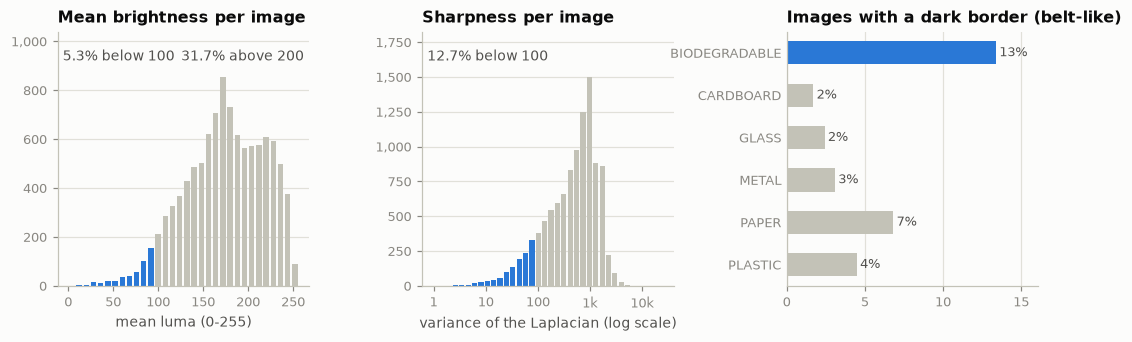

- Images darker than 100: **5.3%**; brighter than 200: **31.7%**; with more than 5% blown-out pixels: **39.6%**.
- Images with sharpness below 100: **12.7%** (below 50: 5.7%).
- Dark borders: BIODEGRADABLE 13% against 7% or less for every other class.

In [11]:
luma, lap = S["luma_mean"], S["lap_var"]
DARK, BRIGHT, SOFT = 100, 200, 100
p_dark, p_bright, p_soft = (
    100 * (luma < DARK).mean(),
    100 * (luma > BRIGHT).mean(),
    100 * (lap < SOFT).mean(),
)
dark_border = S["ring_mean"] < 90
dark_border_share = np.array([100 * dark_border[majority == c].mean() for c in range(NC)])

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), gridspec_kw={"wspace": 0.45})
edges = np.arange(0, 264, 8)
hist, _ = np.histogram(luma, bins=edges)
axes[0].bar(
    edges[:-1] + 4, hist, width=6, color=[ACCENT if e + 8 <= DARK else CONTEXT for e in edges[:-1]]
)
axes[0].set_ylim(0, hist.max() * 1.22)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].set_title("Mean brightness per image")
axes[0].set_xlabel("mean luma (0-255)")
axes[0].text(
    0.02,
    0.93,
    f"{p_dark:.1f}% below {DARK}",
    transform=axes[0].transAxes,
    va="top",
    fontsize=9,
    color=INK_2,
)
axes[0].text(
    0.98,
    0.93,
    f"{p_bright:.1f}% above {BRIGHT}",
    transform=axes[0].transAxes,
    va="top",
    ha="right",
    fontsize=9,
    color=INK_2,
)
axes[0].grid(axis="x", visible=False)

log_lap = np.log10(lap + 1)
edges = np.linspace(0, 4.4, 37)
hist, _ = np.histogram(log_lap, bins=edges)
axes[1].bar(
    edges[:-1] + 0.05,
    hist,
    width=0.1,
    color=[ACCENT if e + 0.122 <= np.log10(SOFT + 1) else CONTEXT for e in edges[:-1]],
)
axes[1].set_xticks([0, 1, 2, 3, 4], ["1", "10", "100", "1k", "10k"])
axes[1].set_ylim(0, hist.max() * 1.22)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[1].set_title("Sharpness per image")
axes[1].set_xlabel("variance of the Laplacian (log scale)")
axes[1].text(
    0.02,
    0.93,
    f"{p_soft:.1f}% below {SOFT}",
    transform=axes[1].transAxes,
    va="top",
    fontsize=9,
    color=INK_2,
)
axes[1].grid(axis="x", visible=False)

hbar(
    axes[2], CLASS_NAMES, dark_border_share, highlight=0, fmt="{:.0f}%", xlim=max(dark_border_share)
)
axes[2].set_title("Images with a dark border (belt-like)")
plt.show()

display(
    Markdown(
        f"- Images darker than {DARK}: **{p_dark:.1f}%**; brighter than {BRIGHT}: **{p_bright:.1f}%**; "
        f"with more than 5% blown-out pixels: **{100 * (S['clip_hi'] > 0.05).mean():.1f}%**.\n"
        f"- Images with sharpness below {SOFT}: **{p_soft:.1f}%** (below 50: {100 * (lap < 50).mean():.1f}%).\n"
        f"- Dark borders: {CLASS_NAMES[0]} {dark_border_share[0]:.0f}% against {np.delete(dark_border_share, 0).max():.0f}% or less for every other class."
    )
)

**Reading.** Brightness varies a lot, but almost all of it sits at the bright end: the dark end, which is what a
belt under fixed lighting will often look like, is nearly empty. Sharpness is similar: almost everything is crisp.
And the few dark backgrounds that exist belong overwhelmingly to BIODEGRADABLE (right panel), so a dark backdrop
currently _predicts_ the class.

**Implication.** Add coverage where the data is empty instead of adding jitter everywhere: darkening (one-sided, so
`hsv_v` alone is not the right tool) and blur. Section 8 measures whether the policy actually fills those gaps.


## 5. Colour as a class cue

Colour jitter is only safe if colour is not what tells classes apart. For up to three random boxes per image:
the hue of the box's coloured pixels (degrees on the colour wheel, 0 = red) and how much of the box is coloured.


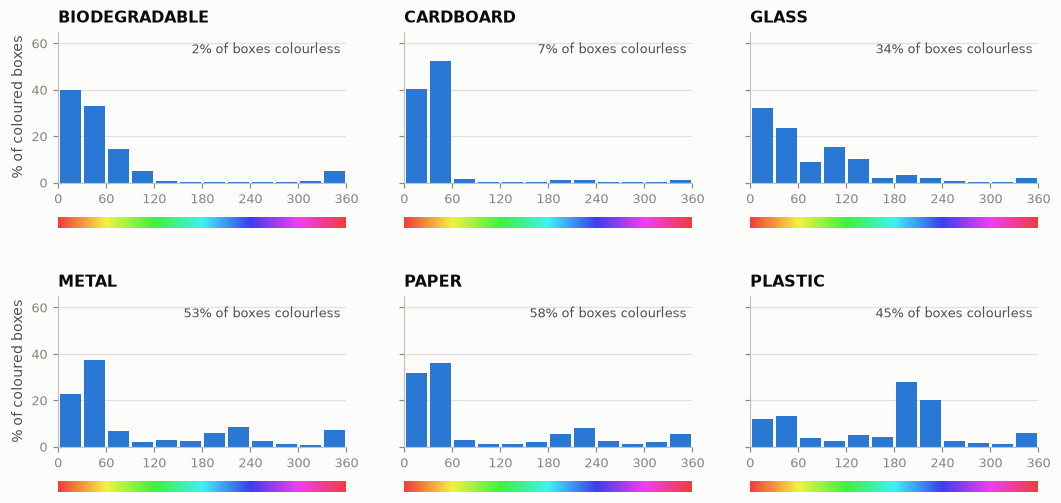

**Table twin** (hue shares are among boxes with coloured pixels; saturation is 0-255)

| class | boxes sampled | median saturation | colourless | hue 0-60 | hue 0-90 | hue 180-240 |
|---|---|---|---|---|---|---|
| BIODEGRADABLE | 5,459 | 138 | 2% | 73% | 87% | 1% |
| CARDBOARD | 2,424 | 87 | 7% | 93% | 94% | 2% |
| GLASS | 3,831 | 83 | 34% | 56% | 64% | 5% |
| METAL | 2,729 | 37 | 53% | 60% | 67% | 14% |
| PAPER | 2,535 | 32 | 58% | 68% | 71% | 14% |
| PLASTIC | 2,628 | 50 | 45% | 25% | 29% | 48% |

In [12]:
colors = np.array(
    [(c, s, ch, hue) for boxes in BOX_COLORS for (c, s, ch, hue) in boxes]
)  # class, sat, chroma share, hue


def hue_share(hue, low, high):
    return f"{100 * ((hue >= low) & (hue < high)).mean():.0f}%"


fig, axes = plt.subplots(2, 3, figsize=(11.5, 4.9), sharey=True)
strip = hsv_to_rgb(
    np.dstack([np.linspace(0, 1, 360)[None, :], np.full((1, 360), 0.75), np.full((1, 360), 0.95)])
)
table_rows = []
for c, ax in enumerate(axes.ravel()):
    mine = colors[colors[:, 0] == c]
    hue = mine[~np.isnan(mine[:, 3]), 3]
    achromatic = 100 * (mine[:, 2] < 0.3).mean()
    hist, _ = np.histogram(hue, bins=np.arange(0, 361, 30))
    ax.bar(np.arange(12) * 30 + 15, 100 * hist / len(hue), width=26, color=ACCENT)
    ax.set_title(CLASS_NAMES[c])
    ax.set_xlim(0, 360)
    ax.set_ylim(0, 65)
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
    ax.grid(axis="x", visible=False)
    ax.text(
        0.98,
        0.93,
        f"{achromatic:.0f}% of boxes colourless",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        color=INK_2,
    )
    inset = ax.inset_axes([0, -0.3, 1, 0.07])
    inset.imshow(strip, aspect="auto", extent=[0, 360, 0, 1])
    inset.axis("off")
    table_rows.append([CLASS_NAMES[c], f"{len(mine):,}", f"{np.median(mine[:, 1]):.0f}", f"{achromatic:.0f}%",
                       hue_share(hue, 0, 60), hue_share(hue, 0, 90), hue_share(hue, 180, 240)])  # fmt: skip
axes[0, 0].set_ylabel("% of coloured boxes")
axes[1, 0].set_ylabel("% of coloured boxes")
fig.subplots_adjust(hspace=0.75)
plt.show()
display(
    Markdown(
        "**Table twin** (hue shares are among boxes with coloured pixels; saturation is 0-255)"
    )
)
display(
    md_table(
        [
            "class",
            "boxes sampled",
            "median saturation",
            "colourless",
            "hue 0-60",
            "hue 0-90",
            "hue 180-240",
        ],
        table_rows,
    )
)

**Reading.** Three classes are defined by hue: cardboard is brown, biodegradable is warm (red to yellow-green) and
plastic clusters in cyan-blue; metal and paper are mostly colourless.

**Implication.** Leave hue jitter (`hsv_h`) at its default and do not raise it. Saturation is the risk: washing
out colour turns cardboard and organic waste into something that looks like paper or metal, so `hsv_s` at its
default of 0.7 is the setting to ablate (arm `proposed_low_saturation`). That is a hypothesis to test, not a
finding.


## 6. Can a model cheat on how the photo looks?

If the class can be guessed from global photo statistics alone, the model may learn the photo style instead of the
object, and then fail on a belt where every item sits on the same background. Test: predict each image's main class
from 12 numbers (brightness, contrast, colour, saturation, sharpness, clipping) with no shape or position
information, using 5-fold cross-validation.


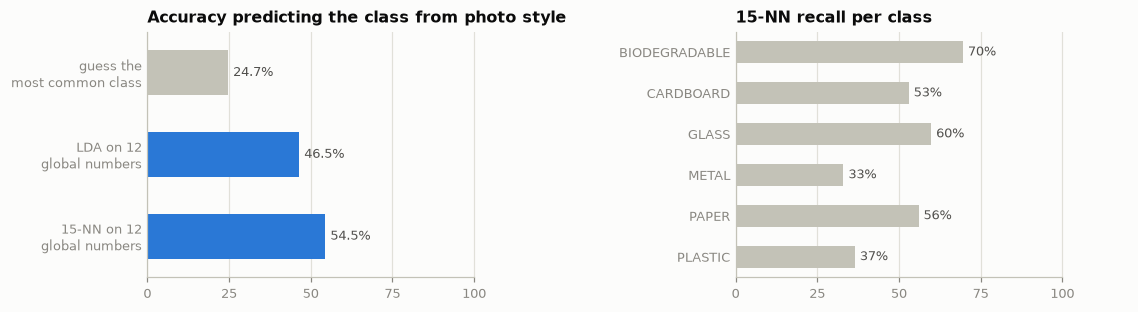

- Guessing the most common class: **24.7%**. LDA on the 12 numbers: **46.5%**. 15-NN: **54.5%** (5-fold cross-validation).
- Recall per class (15-NN): BIODEGRADABLE 70%, CARDBOARD 53%, GLASS 60%, METAL 33%, PAPER 56%, PLASTIC 37%.

In [13]:
def shortcut_test(X, y, folds=5, seed=0, k=15):
    # linear discriminant analysis and k-nearest-neighbours, both from numpy
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    fold = np.random.default_rng(seed).permutation(len(y)) % folds
    classes = np.unique(y)
    lda, knn = np.empty_like(y), np.empty_like(y)
    for f in range(folds):
        tr, te = fold != f, fold == f
        means = np.stack([X[tr & (y == c)].mean(axis=0) for c in classes])
        pooled = sum(np.cov(X[tr & (y == c)].T) * ((tr & (y == c)).sum() - 1) for c in classes) / (
            tr.sum() - len(classes)
        )
        precision = np.linalg.pinv(pooled + 1e-3 * np.eye(X.shape[1]))
        prior = np.log(np.bincount(y[tr], minlength=len(classes)) / tr.sum())
        scores = (
            X[te] @ precision @ means.T
            - 0.5 * np.einsum("cd,dk,ck->c", means, precision, means)
            + prior
        )
        lda[te] = scores.argmax(axis=1)
        dist = (X[te] ** 2).sum(1)[:, None] + (X[tr] ** 2).sum(1)[None] - 2 * X[te] @ X[tr].T
        nearest = np.argpartition(dist, k, axis=1)[:, :k]
        knn[te] = [np.bincount(y[tr][row], minlength=len(classes)).argmax() for row in nearest]
    return lda, knn


lda_pred, knn_pred = shortcut_test(STATS[:, :N_GLOBAL].astype(float), majority)
acc_guess = np.bincount(majority).max() / N
acc_lda, acc_knn = (lda_pred == majority).mean(), (knn_pred == majority).mean()
recall = np.array([(knn_pred[majority == c] == c).mean() * 100 for c in range(NC)])

fig, axes = plt.subplots(
    1, 2, figsize=(11.5, 2.9), gridspec_kw={"width_ratios": [1, 1], "wspace": 0.5}
)
hbar(
    axes[0],
    ["guess the\nmost common class", "LDA on 12\nglobal numbers", "15-NN on 12\nglobal numbers"],
    [100 * acc_guess, 100 * acc_lda, 100 * acc_knn],
    fmt="{:.1f}%",
    percent=True,
)
for bar in axes[0].patches[1:]:  # the two classifiers in the accent, the guess stays grey
    bar.set_facecolor(ACCENT)
axes[0].set_title("Accuracy predicting the class from photo style")
hbar(axes[1], CLASS_NAMES, recall, fmt="{:.0f}%", percent=True)
axes[1].set_title("15-NN recall per class")
plt.show()

display(
    Markdown(
        f"- Guessing the most common class: **{100 * acc_guess:.1f}%**. LDA on the 12 numbers: **{100 * acc_lda:.1f}%**. "
        f"15-NN: **{100 * acc_knn:.1f}%** (5-fold cross-validation).\n"
        "- Recall per class (15-NN): "
        + ", ".join(f"{n} {r:.0f}%" for n, r in zip(CLASS_NAMES, recall))
        + "."
    )
)

**Reading.** Twelve numbers that say nothing about the objects predict the class about twice as well as guessing.
Photo style leaks the label, and a belt (one background, one camera) will not give the model that crutch.

**Implication.** Two levers act on exactly this: mosaic, which puts tiles from different images (so different
backgrounds and classes) side by side, and photometric jitter. Both are in the policy.


## 7. Near-duplicates (a note for the data pipeline, not for augmentation)

If the same picture sits in train and test, test scores are inflated. Roboflow's flips and turns hide duplicates
from a plain comparison, so every image is compared with all 8 flips and 90-degree turns of every other one
(correlation of 32x32 thumbnails, threshold 0.98; pairs in the 0.98+ range were checked by eye and are the same
photo).


- **127** near-duplicate pairs involving **237** images (2.3% of the dataset).
- Pairs by split: test-test 1, test-train 15, test-val 3, train-train 67, train-val 32, val-val 9.
- Test images with a twin in train: **15** of 1045 (1.4%); val images with one: 30 of 2093 (1.4%).

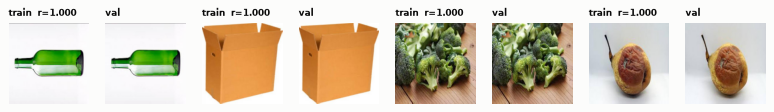

In [14]:
def near_duplicates(thumbs, threshold=0.98, block=1024):
    flat = thumbs.reshape(len(thumbs), -1).astype(np.float32)
    flat_ok = flat.std(axis=1) >= 5  # near-uniform thumbnails make correlation meaningless
    z = flat - flat.mean(axis=1, keepdims=True)
    z /= np.maximum(np.linalg.norm(z, axis=1, keepdims=True), 1e-6)
    z = z.reshape(-1, THUMB, THUMB)
    variants = []
    for mirror in (False, True):
        base = z[:, :, ::-1] if mirror else z
        for turns in range(4):
            variants.append(
                np.ascontiguousarray(np.rot90(base, turns, axes=(1, 2))).reshape(len(z), -1)
            )
    pairs = []
    for start in range(0, len(z), block):
        chunk = z[start : start + block].reshape(-1, THUMB * THUMB)
        sims = chunk @ variants[0].T
        for variant in variants[1:]:
            np.maximum(sims, chunk @ variant.T, out=sims)
        sims[:, ~flat_ok] = -1
        sims[~flat_ok[start : start + block], :] = -1
        rows, cols = np.where(sims >= threshold)
        pairs += [(r + start, c, float(sims[r, c])) for r, c in zip(rows, cols) if c > r + start]
    return pairs


pairs = near_duplicates(THUMBS)
in_pairs = {i for i, j, _ in pairs} | {j for i, j, _ in pairs}
by_split = Counter("-".join(sorted((split_of[i], split_of[j]))) for i, j, _ in pairs)
test_with_twin = {
    (i if split_of[i] == "test" else j)
    for i, j, _ in pairs
    if {split_of[i], split_of[j]} == {"train", "test"}
}
val_with_twin = {
    (i if split_of[i] == "val" else j)
    for i, j, _ in pairs
    if {split_of[i], split_of[j]} == {"train", "val"}
}
n_test, n_val = int((split_of == "test").sum()), int((split_of == "val").sum())
display(
    Markdown(
        f"- **{len(pairs)}** near-duplicate pairs involving **{len(in_pairs)}** images ({100 * len(in_pairs) / N:.1f}% of the dataset).\n"
        f"- Pairs by split: " + ", ".join(f"{k} {v}" for k, v in sorted(by_split.items())) + ".\n"
        f"- Test images with a twin in train: **{len(test_with_twin)}** of {n_test} ({100 * len(test_with_twin) / n_test:.1f}%); "
        f"val images with one: {len(val_with_twin)} of {n_val} ({100 * len(val_with_twin) / n_val:.1f}%)."
    )
)

cross = sorted([p for p in pairs if split_of[p[0]] != split_of[p[1]]], key=lambda p: -p[2])[:4]
fig, axes = plt.subplots(1, 8, figsize=(11.5, 1.75), dpi=PHOTO_DPI)
for n, (i, j, sim) in enumerate(cross):
    for k, idx in enumerate((i, j)):
        axes[2 * n + k].imshow(io.load_image(paths[idx]))
        axes[2 * n + k].axis("off")
        axes[2 * n + k].set_title(
            f"{split_of[idx]}" + (f"  r={sim:.3f}" if k == 0 else ""), fontsize=8, loc="left"
        )
plt.show()

## 8. From evidence to policy

| Measured gap                                                                                        | Lever                                                                                                                                                           | Arm                                |
| --------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------- |
| About 30% of images still in natural orientation; Roboflow randomised the rest once (section 1)     | `flipud=0.5` on top of the default `fliplr=0.5`                                                                                                                 | `proposed`                         |
| The dark end of brightness is nearly empty (section 4)                                              | `RandomBrightnessContrast`, darkening only                                                                                                                      | `proposed`                         |
| Almost no blur (section 4)                                                                          | `MotionBlur`, `GaussianBlur`                                                                                                                                    | `proposed`                         |
| Photo style predicts the class; scenes are single-class and mostly single-object (sections 2, 3, 6) | mosaic stays on (Ultralytics default)                                                                                                                           | every arm except `no_augmentation` |
| Colour tells cardboard, organic waste and plastic apart (section 5)                                 | `hsv_h` unchanged; test a lower `hsv_s`                                                                                                                         | `proposed_low_saturation`          |
| Not applicable or not worth it                                                                      | `copy_paste` (needs polygon labels), `erasing` (classification only), arbitrary-angle rotation (loosens boxes, section 9), image-level oversampling (section 2) | none                               |

The policy lives in [`configs/augmentation.yaml`](../configs/augmentation.yaml); this notebook only reads it.

**What this notebook can and cannot render.** It applies the flips and the custom (Albumentations) transforms
exactly as training will. Ultralytics' own settings (`hsv_h`, `hsv_s`, `hsv_v`, `scale`, `translate`, mosaic) run
inside its training loop and are not rendered here. So the checks and previews below show the custom part of an
arm only, and `proposed` and `proposed_low_saturation` look identical in them: they differ only in `hsv_s`.


In [15]:
rows = []
for name in list_arms():
    arm = load_policy(name)
    if arm.ultralytics and set(arm.ultralytics.values()) == {0.0}:
        overrides = "every augmentation parameter = 0"
    else:
        overrides = (
            ", ".join(f"{k}={v}" for k, v in arm.ultralytics.items())
            or "none (Ultralytics defaults)"
        )
    custom = ", ".join(t["name"] for t in arm.custom) or "none"
    rows.append([f"`{name}`", overrides, custom, arm.description])
display(md_table(["arm", "Ultralytics overrides", "custom transforms", "what it is"], rows))

| arm | Ultralytics overrides | custom transforms | what it is |
|---|---|---|---|
| `no_augmentation` | every augmentation parameter = 0 | none | Floor of the ablation. Every Ultralytics augmentation parameter zeroed. |
| `ultralytics_defaults` | none (Ultralytics defaults) | none | Baseline. Pass nothing, so whatever the pinned Ultralytics defaults are (mosaic, HSV jitter, fliplr, translate, scale). Name this arm "Ultralytics defaults" in the paper, never "no augmentation". |
| `proposed` | flipud=0.5 | RandomBrightnessContrast, MotionBlur, GaussianBlur | Ultralytics defaults plus the gaps measured in the data: missing orientations, a missing dark tail, and almost no blur. hsv_h stays at its default: class hues are narrow (cardboard 93% within 0-60 deg, biodegradable 87% within 0-90 deg), so it should not grow. Mosaic stays on (default) because 90% of images hold a single class and 49% a single object. |
| `proposed_low_saturation` | flipud=0.5, hsv_s=0.5 | RandomBrightnessContrast, MotionBlur, GaussianBlur | proposed plus a weaker saturation jitter. Cardboard and biodegradable boxes are almost never colourless (7% and 2%) while paper and metal mostly are (58% and 53%), so colour is what separates them, and the default hsv_s of 0.7 can wash it out. A hypothesis to test, not a finding. |

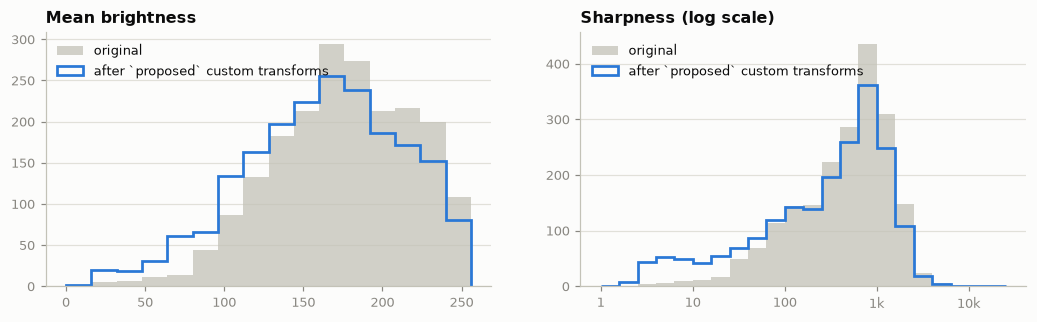

| 2,000 random train images | original | after `proposed` (custom transforms) |
|---|---|---|
| images with mean brightness < 100 | 4.9% | 11.6% |
| median brightness | 177 | 166 |
| images with sharpness < 100 | 14.0% | 26.1% |

In [16]:
# Do the custom transforms fill the gaps they target? Apply them to 2000 random train images and compare.
# Ultralytics' own hsv_v jitter also acts at train time and widens brightness further, so this is a floor.
N_CHECK = 2000
policy = load_policy(ARM)
train_idx = np.where(split_of == "train")[0]
sample = np.random.default_rng(SEED).choice(train_idx, N_CHECK, replace=False)


def luma_and_sharpness(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    return gray.mean(), cv2.Laplacian(gray, cv2.CV_64F).var()


before, after = [], []
for n, i in enumerate(sample):
    image = io.load_image(paths[i])
    augmented, _ = augment_sample(policy, image, boxes_of[i], seed=SEED + n)
    before.append(luma_and_sharpness(image))
    after.append(luma_and_sharpness(augmented))
before, after = np.array(before), np.array(after)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.0))
for ax, col, bins, title, ticks in (
    (axes[0], 0, np.arange(0, 272, 16), "Mean brightness", None),
    (
        axes[1],
        1,
        np.linspace(0, 4.4, 23),
        "Sharpness (log scale)",
        ([0, 1, 2, 3, 4], ["1", "10", "100", "1k", "10k"]),
    ),
):
    b, a = before[:, col], after[:, col]
    if col == 1:
        b, a = np.log10(b + 1), np.log10(a + 1)
    ax.hist(b, bins=bins, color=CONTEXT, alpha=0.75, label="original")
    ax.hist(
        a,
        bins=bins,
        histtype="step",
        color=ACCENT,
        linewidth=1.8,
        label=f"after `{ARM}` custom transforms",
    )
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
    if ticks:
        ax.set_xticks(*ticks)
    ax.legend(loc="upper left")
plt.show()

rows = [
    [
        f"images with mean brightness < {DARK}",
        f"{100 * (before[:, 0] < DARK).mean():.1f}%",
        f"{100 * (after[:, 0] < DARK).mean():.1f}%",
    ],
    ["median brightness", f"{np.median(before[:, 0]):.0f}", f"{np.median(after[:, 0]):.0f}"],
    [
        f"images with sharpness < {SOFT}",
        f"{100 * (before[:, 1] < SOFT).mean():.1f}%",
        f"{100 * (after[:, 1] < SOFT).mean():.1f}%",
    ],
]
display(
    md_table(
        [f"{N_CHECK:,} random train images", "original", f"after `{ARM}` (custom transforms)"], rows
    )
)

**Reading.** Applied to real train images, the custom transforms alone roughly double the share of dark and of soft
images (table) while leaving the bulk of the data (median brightness, most sharp images) where it was. This is a
floor on the effect of the arm: at train time Ultralytics' own `hsv_v` jitter widens brightness in both
directions on top of it, and that part is not rendered here. The magnitudes are starting points: with belt frames
they should be tuned until the augmented distribution resembles them.


## 9. Preview: what the model will see

Boxes must follow the pixels. Lossless transforms (flips, 90-degree turns) keep them tight; rotating by an
arbitrary angle makes an axis-aligned box grow, because the box has to contain the rotated object's corners.
The table gives the upper bound for this dataset's own box shapes (it assumes the object fills its box).


In [17]:
ratio = BOX[:, 4] / BOX[:, 3]  # height / width of every box


def hull_growth(degrees):
    c, s = np.cos(np.radians(degrees)), np.sin(np.radians(degrees))
    return (c + ratio * s) * (s + ratio * c) / ratio  # hull area of the rotated box / original area


rows = [
    [
        f"{d} degrees",
        f"{np.median(hull_growth(d)):.2f}x",
        f"{np.percentile(hull_growth(d), 90):.2f}x",
    ]
    for d in (5, 10, 20, 45)
]
display(md_table(["rotation", "median box-area growth", "90th percentile"], rows))

| rotation | median box-area growth | 90th percentile |
|---|---|---|
| 5 degrees | 1.19x | 1.29x |
| 10 degrees | 1.37x | 1.57x |
| 20 degrees | 1.70x | 2.07x |
| 45 degrees | 2.09x | 2.67x |

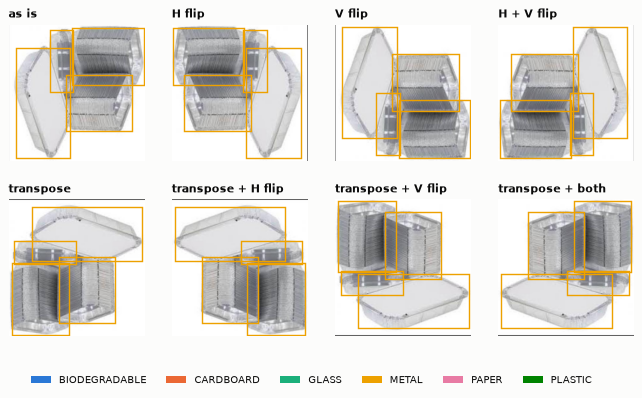

In [18]:
# The 8 lossless orientations (flips and 90-degree turns) of one train image. Boxes stay tight.
VARIANTS = [
    ("as is", 0, 0, 0), ("H flip", 0, 1, 0), ("V flip", 0, 0, 1), ("H + V flip", 0, 1, 1),
    ("transpose", 1, 0, 0), ("transpose + H flip", 1, 1, 0), ("transpose + V flip", 1, 0, 1), ("transpose + both", 1, 1, 1),
]  # fmt: skip
demo = int(
    np.random.default_rng(SEED).choice(
        train_idx[(majority[train_idx] == 3) & (n_boxes[train_idx] >= 2)]
    )
)
demo_image = io.load_image(paths[demo])
fig, axes = plt.subplots(2, 4, figsize=(9.5, 4.9), dpi=PHOTO_DPI)
for ax, (label, t, h, v) in zip(axes.ravel(), VARIANTS):
    pipeline = A.Compose(
        [A.Transpose(p=float(t)), A.HorizontalFlip(p=float(h)), A.VerticalFlip(p=float(v))],
        bbox_params=A.BboxParams(format="yolo", label_fields=["class_ids"], clip=True),
    )
    out = pipeline(
        image=demo_image,
        bboxes=boxes_of[demo][:, 1:].tolist(),
        class_ids=boxes_of[demo][:, 0].astype(int).tolist(),
    )
    draw_boxes(
        ax,
        out["image"],
        np.hstack(
            [
                np.array(out["class_ids"], dtype=float)[:, None],
                np.array(out["bboxes"]).reshape(-1, 4),
            ]
        ),
    )
    ax.set_title(label, fontsize=9)
class_legend(fig, y=-0.02)
plt.show()

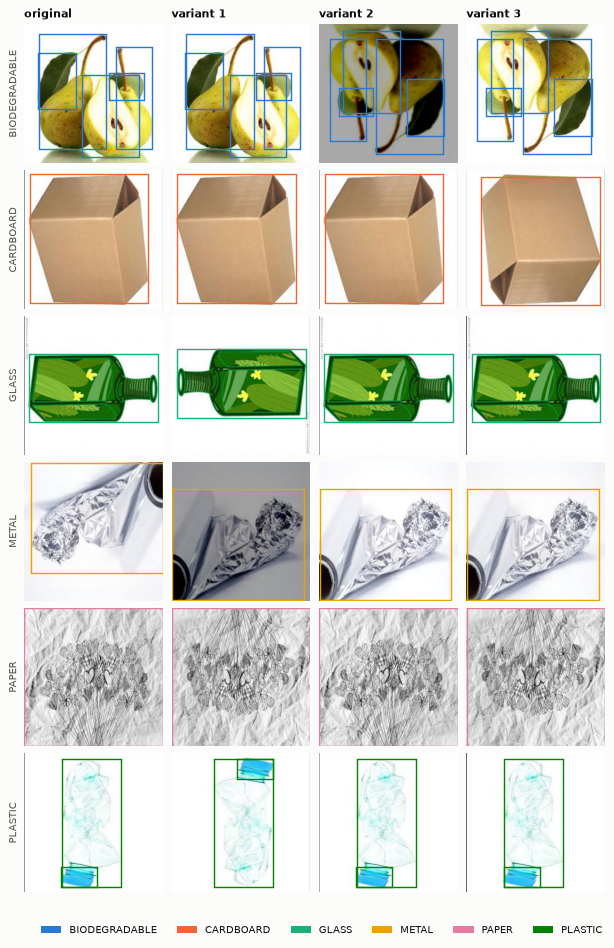

In [19]:
# The chosen arm applied to one train image per class (flips as configured + the custom transforms).
# Ultralytics' own HSV jitter, scale/translate and mosaic run inside its training loop and are not reproduced here.
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(NC, 4, figsize=(8.4, 2.05 * NC), dpi=PHOTO_DPI)
for c in range(NC):
    i = int(rng.choice(train_idx[majority[train_idx] == c]))
    image = io.load_image(paths[i])
    draw_boxes(axes[c, 0], image, boxes_of[i])
    axes[c, 0].text(
        -0.04,
        0.5,
        CLASS_NAMES[c],
        transform=axes[c, 0].transAxes,
        rotation=90,
        ha="right",
        va="center",
        fontsize=8.5,
        color=INK_2,
    )
    for v in range(3):
        augmented, new_boxes = augment_sample(policy, image, boxes_of[i], seed=SEED + 100 * c + v)
        draw_boxes(axes[c, v + 1], augmented, new_boxes)
for ax, title in zip(axes[0], ["original", "variant 1", "variant 2", "variant 3"]):
    ax.set_title(title, fontsize=9)
class_legend(fig, y=0.0)
fig.subplots_adjust(left=0.08, bottom=0.05, wspace=0.03, hspace=0.05)
plt.show()

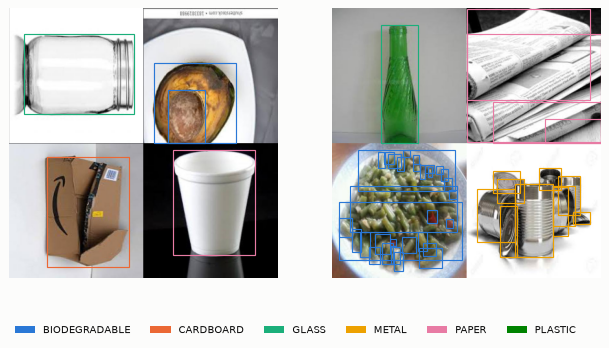

In [20]:
# A simplified mosaic (2x2 tiling) for illustration. Ultralytics runs its own mosaic during training.
rng = np.random.default_rng(SEED + 1)
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.6), dpi=PHOTO_DPI)
for ax in axes:
    picks = [
        int(rng.choice(train_idx[majority[train_idx] == c]))
        for c in rng.choice(NC, 4, replace=False)
    ]
    canvas, mosaic_boxes = simple_mosaic(
        [(io.load_image(paths[i]), boxes_of[i]) for i in picks], size=IMG
    )
    draw_boxes(ax, canvas, mosaic_boxes, linewidth=1.0)
class_legend(fig, y=-0.02)
plt.show()

Wrote **144** augmented images (arm `proposed`, 48 train images x 3 variants, 7.7 MB) to `data/augmented/`, plus contact sheets in `preview/`. `data/processed/` is unchanged and every source image is from train.

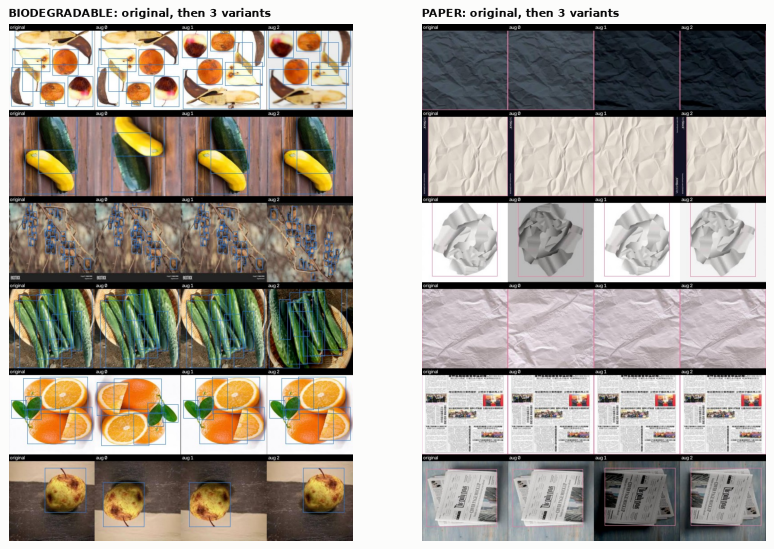

In [21]:
def fingerprint(root):
    files = [p for p in Path(root).rglob("*") if p.is_file()]
    return len(files), sum(p.stat().st_size for p in files)


if EXPORT_TO_DISK:
    before_processed = fingerprint(PROCESSED_DIR)
    summary = export_preview(policy, PROCESSED_DIR, AUGMENTED_DIR, per_class=PER_CLASS, n_variants=N_VARIANTS,
                             seed=SEED, protected=[RAW_DIR])  # fmt: skip
    exported = {
        p.stem.rsplit("__aug", 1)[0] for p in (AUGMENTED_DIR / "images" / "train").glob("*.jpg")
    }
    assert fingerprint(PROCESSED_DIR) == before_processed, "data/processed changed"
    assert exported <= set(stems[split_of == "train"]), (
        "the export used images that are not from train"
    )
    size_mb = sum(p.stat().st_size for p in AUGMENTED_DIR.rglob("*") if p.is_file()) / 1e6
    display(
        Markdown(
            f"Wrote **{summary.files_written}** augmented images (arm `{ARM}`, {summary.source_images} train images x {N_VARIANTS} variants, "
            f"{size_mb:.1f} MB) to `{AUGMENTED_DIR.relative_to(ROOT)}/`, plus contact sheets in `preview/`. "
            "`data/processed/` is unchanged and every source image is from train."
        )
    )
    shown = [s for s in summary.sheets if s.stem in (CLASS_NAMES[0], CLASS_NAMES[4])]
    fig, axes = plt.subplots(1, len(shown), figsize=(11.5, 8.6), dpi=PHOTO_DPI)
    for ax, sheet in zip(np.atleast_1d(axes), shown):
        ax.imshow(cv2.cvtColor(cv2.imread(str(sheet)), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{sheet.stem}: original, then 3 variants", fontsize=9)
        ax.axis("off")
    plt.show()
else:
    print("EXPORT_TO_DISK is False: nothing was written.")

## 10. Hand-off

**For Julia (training).** The policy is one YAML file plus a small loader; nothing is generated on disk.

```python
from vpc2.data.augmentation import load_policy

policy = load_policy("proposed")  # or any arm in configs/augmentation.yaml
model.train(data="data/processed/data.yaml", **policy.train_kwargs())
```

What `train_kwargs()` hands over for each arm (custom transforms are Albumentations objects):


In [22]:
for name in list_arms():
    kwargs = load_policy(name).train_kwargs()
    shown = {
        k: ([type(t).__name__ for t in v] if k == "augmentations" else v) for k, v in kwargs.items()
    }
    print(f"{name:<26}", shown if len(shown) < 6 else f"{len(shown)} parameters, all 0.0")

no_augmentation            15 parameters, all 0.0
ultralytics_defaults       {}
proposed                   {'flipud': 0.5, 'augmentations': ['RandomBrightnessContrast', 'MotionBlur', 'GaussianBlur']}
proposed_low_saturation    {'flipud': 0.5, 'hsv_s': 0.5, 'augmentations': ['RandomBrightnessContrast', 'MotionBlur', 'GaussianBlur']}


**Ablation to report** (per-class AP and mAP on the test split; same seed and epochs for every arm):
`no_augmentation`, `ultralytics_defaults`, `proposed`, `proposed_low_saturation`. Fewer arms is fine;
`ultralytics_defaults` versus `proposed` is the essential pair. Name the baseline **"Ultralytics defaults"**, never
"no augmentation": Ultralytics augments by default.

**Verified here**

- Ultralytics parameter names and defaults, against its `main` config and docs (2026-09-23).
- Flips and 90-degree turns move YOLO boxes correctly in Albumentations, and every transform is reproducible from a
  seed (tests in `tests/test_augmentation.py`).

**Not verified until `ultralytics` is installed** (check on the first training run)

- How `augmentations=` interacts with Ultralytics' own Albumentations defaults (Blur, MedianBlur, ToGray and CLAHE at
  p=0.01): replace or extend.
- `auto_augment`, whose docs are ambiguous, and that spatial transforms such as `RandomRotate90` survive its
  pipeline end to end.
- The claim that a belt differs from this data rests on the case study (Shukhratov et al., 2024) and on how the images
  look; the repo has no belt frames. Even ~100 annotated frames from the demo video would show whether the policy helps
  where it matters and would let the magnitudes be tuned.

**Outside augmentation (found on the way)**

- About 70% of every processed split, test included, comes from Roboflow's flipped-and-turned train split
  (section 1), so the test set is not in natural orientation.
- Section 7: a small share of test images have a near-duplicate in train. A group-aware split would remove it.
